# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings



In [ ]:
# Import the libraries you will be using for analysis



In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os
import pandas as pd
# Select the folder having data files
#os.chdir('/content/Assignments/EDA/data_NYC_Taxi/trip_records')

os.chdir(f'D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Files\\')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()

all_sampled_list = []
# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        sampled_list = []
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        df = pd.read_parquet(file_path)
        df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
        df = df.sort_values(by='tpep_pickup_datetime')
        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date
        for (date, hour), hourly_data in df.groupby([df['tpep_pickup_datetime'].dt.date, df['tpep_pickup_datetime'].dt.hour]):
                # Sample 5% of the hourly data randomly
                if len(hourly_data) > 1:
                    sampled_hourly_data = hourly_data.sample(frac=0.05, random_state=42)
                else:
                    sampled_hourly_data = hourly_data

                sampled_list.append(sampled_hourly_data)    
                
        sampled_data = pd.concat(sampled_list, ignore_index=True)
        all_sampled_list.append(sampled_data)

        print(f"Processed {file_name} successfully.")        
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

final_sampled_data = pd.concat(all_sampled_list, ignore_index=True)
output_file = os.path.join(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\", "Combine_yellow_tripdata_2023.parquet")
final_sampled_data.to_parquet(output_file)

print(f"Final sampled data saved to {output_file}")        

Final sampled data saved to D:\WorkSpace\Assignment\EDA_Optimising_NYC_Taxis\Data\Combine_yellow_tripdata_2023.parquet


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
# df.to_parquet('')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [19]:
# Load the new data file
import pandas as pd
df = pd.read_parquet(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet")


In [3]:
import pandas as pd
df = pd.read_parquet(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet")
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-03-07 13:01:28,2023-03-07 13:11:17,1.0,2.84,1.0,N,233,232,1,14.2,1.0,0.5,1.00,0.0,1.0,20.20,2.5,NaN,0.0
1,2,2023-05-03 23:14:53,2023-05-03 23:19:31,2.0,1.30,1.0,N,229,141,1,7.9,0.0,0.5,1.19,0.0,1.0,13.09,2.5,NaN,0.0
2,2,2023-09-05 18:20:48,2023-09-05 18:24:21,1.0,0.45,1.0,N,170,233,1,5.8,1.0,0.5,2.16,0.0,1.0,12.96,2.5,NaN,0.0
3,2,2023-07-01 00:00:09,2023-07-01 00:21:21,1.0,4.49,1.0,N,140,7,1,24.0,1.0,0.5,5.80,0.0,1.0,34.80,2.5,NaN,0.0
4,2,2023-11-23 13:40:43,2023-11-23 14:05:43,1.0,4.41,1.0,N,142,116,1,26.1,0.0,0.5,6.02,0.0,1.0,36.12,2.5,NaN,0.0


In [4]:
import pandas as pd
df = pd.read_parquet(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               6 non-null      int64         
 1   tpep_pickup_datetime   6 non-null      datetime64[us]
 2   tpep_dropoff_datetime  6 non-null      datetime64[us]
 3   passenger_count        6 non-null      float64       
 4   trip_distance          6 non-null      float64       
 5   RatecodeID             6 non-null      float64       
 6   store_and_fwd_flag     6 non-null      object        
 7   PULocationID           6 non-null      int64         
 8   DOLocationID           6 non-null      int64         
 9   payment_type           6 non-null      int64         
 10  fare_amount            6 non-null      float64       
 11  extra                  6 non-null      float64       
 12  mta_tax                6 non-null      float64       
 13  tip_amoun

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [20]:
# Fix the index and drop any columns that are not needed
import pandas as pd

# Load the dataset
parquet_file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(parquet_file_path)
df.reset_index(drop=True, inplace=True)
find_unnecessary_columns = [col for col in df.columns if "unnamed" in col.lower()]
df.drop(columns=find_unnecessary_columns, inplace=True, errors='ignore')
new_file = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Result\\Cleaned_yellow_tripdata_2023_2.1.1.parquet"
df.to_csv(new_file, index=False)
print("Cleaned data saved as:", new_file)


Cleaned data saved as: D:\WorkSpace\Assignment\EDA_Optimising_NYC_Taxis\Data\Result\Cleaned_yellow_tripdata_2023_2.1.1.parquet


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [1]:
# Combine the two airport fee columns
import pandas as pd

# Load the dataset
parquet_file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(parquet_file_path)
df.reset_index(drop=True, inplace=True)
find_unnecessary_columns = [col for col in df.columns if "unnamed" in col.lower()]
df.drop(columns=find_unnecessary_columns, inplace=True, errors='ignore')

if "airport_fee" in df.columns and "Airport_fee" in df.columns:
    df["airport_fee"] = df["airport_fee"].fillna(0) + df["Airport_fee"].fillna(0)
    df.drop(columns=["Airport_fee"], inplace=True)

new_file = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Result\\Cleaned_yellow_tripdata_2023_2.1.2.parquet"
df.to_csv(new_file, index=False)
print("Cleaned data saved as:", new_file)


Cleaned data saved as: D:\WorkSpace\Assignment\EDA_Optimising_NYC_Taxis\Data\Result\Cleaned_yellow_tripdata_2023_2.1.2.parquet


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative



Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts



In [ ]:
# Find which columns have negative values



In [2]:
# fix these negative values
import pandas as pd

parquet_file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(parquet_file_path)
find_monetary_columns = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", 
                    "improvement_surcharge", "total_amount", "congestion_surcharge", "airport_fee"]
find_monetary_columns = [col for col in find_monetary_columns if col in df.columns]
df[find_monetary_columns] = df[find_monetary_columns].clip(lower=0)
corrected_file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Result\\Corrected_yellow_tripdata_2023_2.1.3.csv"
df.to_csv(corrected_file_path, index=False)
print("Corrected data saved as:", corrected_file_path)



Corrected data saved as: D:\WorkSpace\Assignment\EDA_Optimising_NYC_Taxis\Data\Result\Corrected_yellow_tripdata_2023_2.1.3.csv


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [17]:
# Find the proportion of missing values in each column

import pandas as pd

parquet_file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(parquet_file_path)
find_missing_values_ratio = df.isnull().sum() / len(df)
find_missing_values_ratio_percentage = (find_missing_values_ratio * 100).round(2)
print(find_missing_values_ratio_percentage)




VendorID                   0.0
tpep_pickup_datetime       0.0
tpep_dropoff_datetime      0.0
passenger_count            0.0
trip_distance              0.0
RatecodeID                 0.0
store_and_fwd_flag         0.0
PULocationID               0.0
DOLocationID               0.0
payment_type               0.0
fare_amount                0.0
extra                      0.0
mta_tax                    0.0
tip_amount                 0.0
tolls_amount               0.0
improvement_surcharge      0.0
total_amount               0.0
congestion_surcharge       0.0
airport_fee              100.0
Airport_fee                0.0
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [21]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'

import pandas as pd
file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df["passenger_count"].fillna(df["passenger_count"].median())
file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Result\\Cleaned_yellow_tripdata_2023_2.2.2.cparquet"
df.to_csv(file_path, index=False)
print("Cleaned data saved as:", file_path)
print(df)


Cleaned data saved as: D:\WorkSpace\Assignment\EDA_Optimising_NYC_Taxis\Data\Result\Cleaned_yellow_tripdata_2023_2.2.2.cparquet
         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0               2  2022-10-24 17:37:47   2022-10-24 17:37:51              1.0   
1               2  2022-10-24 20:01:46   2022-10-24 20:01:48              1.0   
2               2  2022-10-24 21:45:35   2022-10-24 21:45:38              1.0   
3               2  2022-10-24 23:15:32   2022-10-24 23:15:42              1.0   
4               2  2022-10-25 03:45:46   2022-10-25 03:45:50              1.0   
...           ...                  ...                   ...              ...   
1915620         1  2023-12-31 23:19:30   2023-12-31 23:34:05              1.0   
1915621         2  2024-01-03 10:00:04   2024-01-03 11:08:22              1.0   
1915622         2  2024-01-03 17:00:52   2024-01-03 17:01:05              2.0   
1915623         2  2024-01-03 18:43:26   2024-01-03 18:43:29  

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'
import pandas as pd

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df["RatecodeID"] = df["RatecodeID"].fillna(df["RatecodeID"].mode()[0])
file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Result\\Cleaned_yellow_tripdata_2023.2.2.3.parquet"
df.to_parquet(file_path, index=False)
print("Cleaned data saved as:", file_path)


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge

import pandas as pd


file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(df['congestion_surcharge'].median())
file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Result\\Cleaned_yellow_tripdata_2023.2.2.4.parquet"
df.to_parquet(file_path, index=False)
print("Cleaned data saved as:", file_path)



Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values
import pandas as pd

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)

for col in df.columns:
    if df[col].isna().sum() > 0:  # Check if column has missing values
        if df[col].dtype in ['float64', 'int64']:  
            df[col] = df[col].fillna(df[col].median())  # Fill numeric columns with median
        else:
            df[col] = df[col].fillna(df[col].mode()[0])  # Fill categorical columns with mode


output_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Result\\Cleaned_yellow_tripdata_2023.2.2.4.0.parquet"
df.to_parquet(output_path, index=False)
print(f"Cleaned data saved as: {output_path}")



### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
num_columns = ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
               'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=len(num_columns), ncols=2, figsize=(14, 5 * len(num_columns)))

for i, col in enumerate(num_columns):
    sns.boxplot(x=df[col], ax=axes[i, 0], color='lightblue')
    axes[i, 0].set_title(f'Boxplot of {col}')
    
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()



**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]

In [ ]:
# Continue with outlier handling
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

df = remove_outliers(df, num_columns)


In [ ]:
# Do any columns need standardising?

scaler = StandardScaler()
df[num_columns] = scaler.fit_transform(df[num_columns])

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [ ]:
# Find and show the hourly trends in taxi pickups
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.countplot(x=df['pickup_hour'], palette='coolwarm')
plt.title("Number of Rides by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Rides")
plt.show()


In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.weekday
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.countplot(x=df['pickup_weekday'], palette='viridis')
plt.title("Number of Rides by Day of the Week")
plt.xlabel("Day of the Week (0=Monday, 6=Sunday)")
plt.ylabel("Number of Rides")
plt.show()


In [ ]:
# Show the monthly trends in pickups

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.countplot(x=df['pickup_month'], palette='magma')
plt.title("Number of Rides by Month")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters



Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

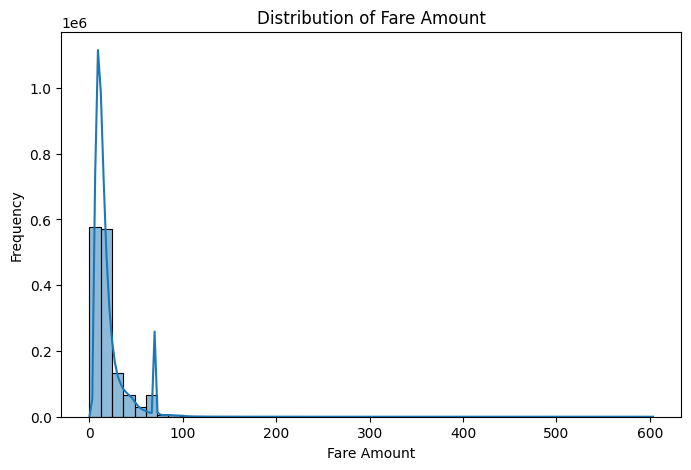

In [3]:
# Create a df with non zero entries for the selected parameters.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
columns_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
df_filtered = df[(df[columns_to_check] > 0).all(axis=1)]
plt.figure(figsize=(8, 5))
sns.histplot(df_filtered['fare_amount'], bins=50, kde=True)
plt.title("Distribution of Fare Amount")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.show()

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

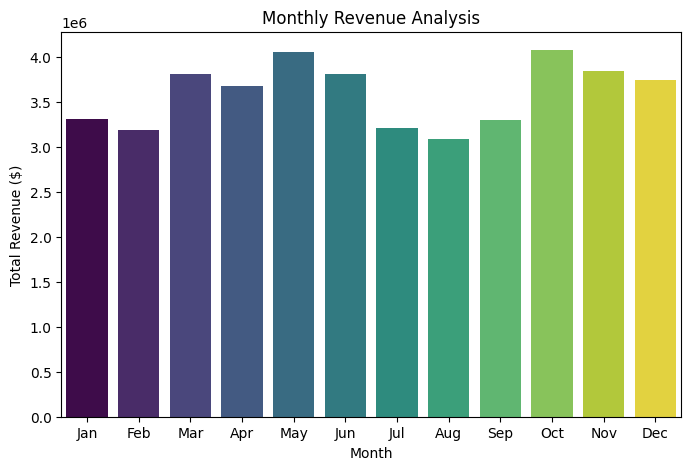

In [9]:
# Group data by month and analyse monthly revenue
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['month'] = df['tpep_pickup_datetime'].dt.month
columns_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
df_filtered = df[(df[columns_to_check] > 0).all(axis=1)]
df_monthly_revenue = df_filtered.groupby('month')['total_amount'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='month', y='total_amount', hue='month', data=df_monthly_revenue, palette='viridis', legend=False)
plt.title("Monthly Revenue Analysis")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

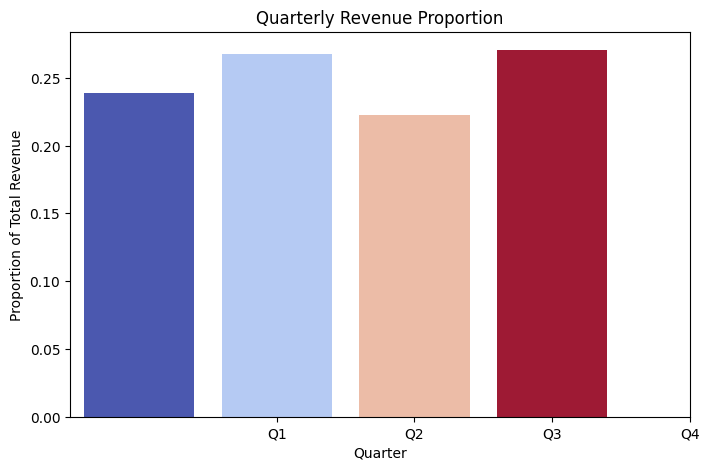

In [5]:
# Calculate proportion of each quarter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['month'] = df['tpep_pickup_datetime'].dt.month
df['quarter'] = df['tpep_pickup_datetime'].dt.quarter
columns_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

# Ensure only existing columns are used for filtering
existing_columns = [col for col in columns_to_check if col in df.columns]

if existing_columns:
    # Filter out rows where any of the selected columns have zero values
    df_filtered = df[(df[existing_columns] > 0).all(axis=1)]
else:
    print("No valid columns found for filtering.")
    df_filtered = df.copy()


df_monthly_revenue = df_filtered.groupby('month')['total_amount'].sum().reset_index()
df_quarterly_revenue = df_filtered.groupby('quarter')['total_amount'].sum().reset_index()
df_quarterly_revenue['proportion'] = df_quarterly_revenue['total_amount'] / df_quarterly_revenue['total_amount'].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x='quarter', y='proportion', hue='quarter', data=df_quarterly_revenue, palette='coolwarm', legend=False)
plt.title("Quarterly Revenue Proportion")
plt.xlabel("Quarter")
plt.ylabel("Proportion of Total Revenue")
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

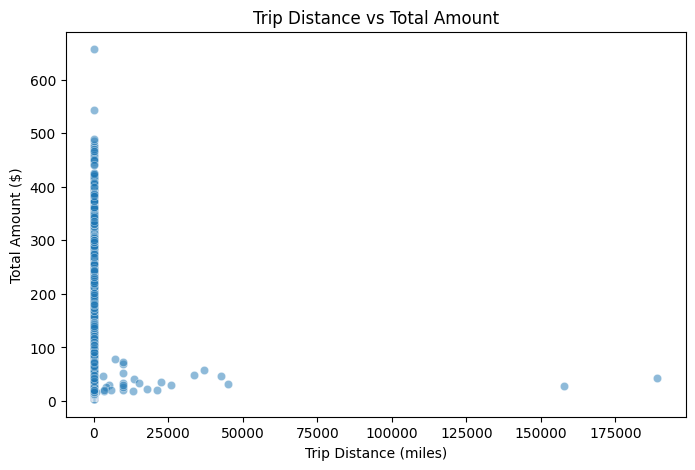

In [10]:
# Show how trip fare is affected by distance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['month'] = df['tpep_pickup_datetime'].dt.month
columns_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
df_filtered = df[(df[columns_to_check] > 0).all(axis=1)]
df_monthly_revenue = df_filtered.groupby('month')['total_amount'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_filtered['trip_distance'], y=df_filtered['total_amount'], alpha=0.5)
plt.title("Trip Distance vs Total Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Total Amount ($)")
plt.show()


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

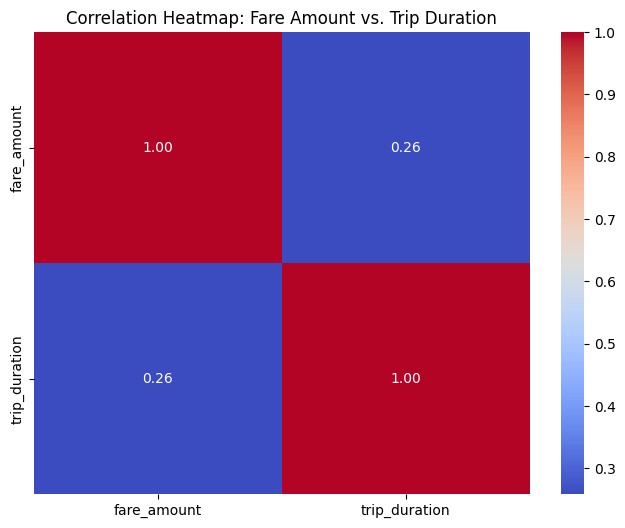

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()
df_filtered = df[['fare_amount', 'trip_duration']].dropna()
correlation_matrix = df_filtered.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap: Fare Amount vs. Trip Duration")
plt.show()


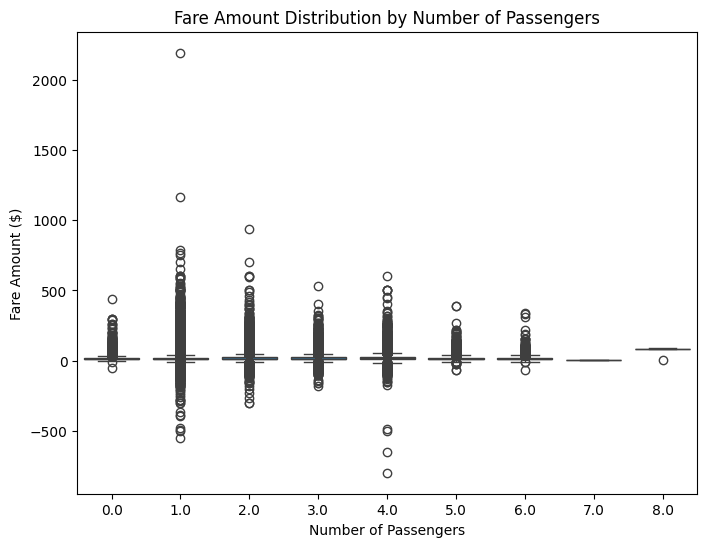

In [13]:
# Show relationship between fare and number of passengers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)


df_filtered = df[['fare_amount', 'passenger_count']].dropna()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_filtered, x='passenger_count', y='fare_amount')
plt.xlabel("Number of Passengers")
plt.ylabel("Fare Amount ($)")
plt.title("Fare Amount Distribution by Number of Passengers")
plt.show()



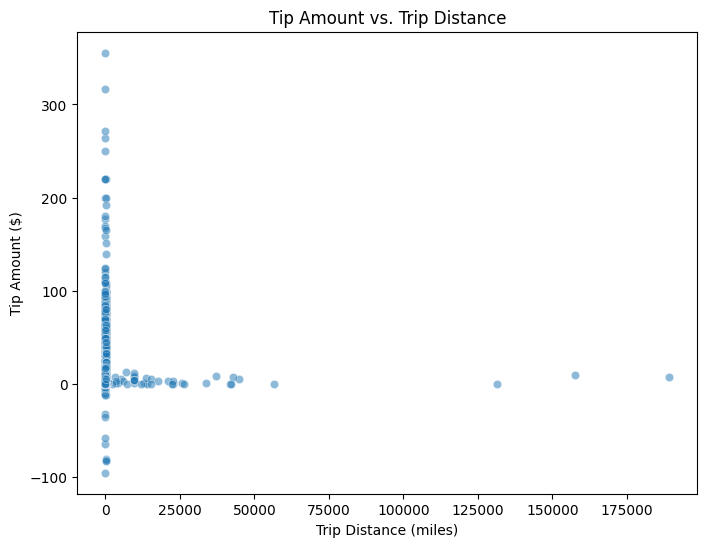

In [14]:
# Show relationship between tip and trip distance

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df_filtered = df[['tip_amount', 'trip_distance']].dropna()
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_filtered, x='trip_distance', y='tip_amount', alpha=0.5)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Tip Amount ($)")
plt.title("Tip Amount vs. Trip Distance")
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

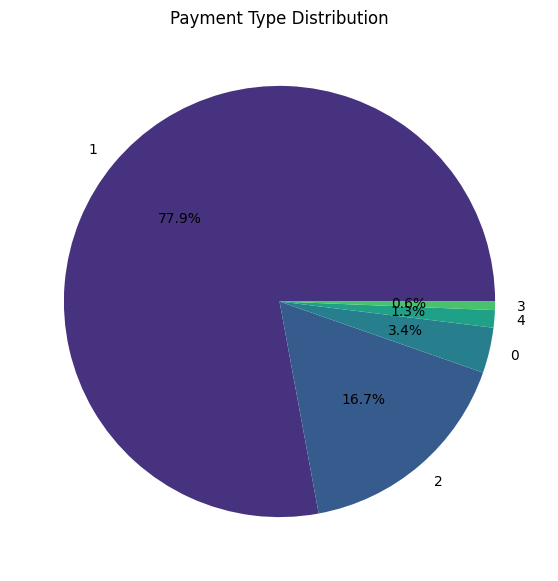

In [3]:
# Analyse the distribution of different payment types (payment_type).

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
payment_counts = df['payment_type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', colors=sns.color_palette("viridis"))
plt.title("Payment Type Distribution")
plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [1]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\taxi_zones\\taxi_zones.shp") # read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

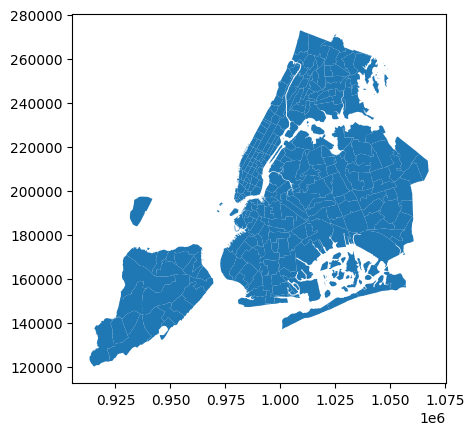

In [2]:
# print(zones.info())
# zones.plot()
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\taxi_zones\\taxi_zones.shp") # read the .shp file using gpd
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [3]:
# Merge zones and trip records using locationID and PULocationID
import geopandas as gpd
import pandas as pd

zones = gpd.read_file(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\taxi_zones\\taxi_zones.shp")
trip_records = pd.read_parquet(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet")
zones = zones.rename(columns={"LocationID": "PULocationID"})
trip_records_merged = trip_records.merge(zones, on="PULocationID", how="left")
print(trip_records_merged.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915766 entries, 0 to 1915765
Data columns (total 26 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [8]:
# Group data by location and calculate the number of trips

import geopandas as gpd
import pandas as pd


zones = gpd.read_file(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\taxi_zones\\taxi_zones.shp")
trip_records = pd.read_parquet(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet")
#print("Trip Records Columns:", trip_records.columns)
#print("Zones Columns:", zones.columns)

zones = zones.rename(columns={"LocationID": "PULocationID"})
trip_records["PULocationID"] = trip_records["PULocationID"].astype(str)
zones["PULocationID"] = zones["PULocationID"].astype(str)
trip_records_merged = trip_records.merge(zones, on="PULocationID", how="left")
trip_counts = trip_records.groupby("PULocationID").size().reset_index(name="trip_count")
zones_trip_data = zones.merge(trip_counts, on="PULocationID", how="left")
zones_trip_data["trip_count"] = zones_trip_data["trip_count"].fillna(0)  
print(zones_trip_data)



     OBJECTID  Shape_Leng  Shape_Area                     zone PULocationID  \
0           1    0.116357    0.000782           Newark Airport            1   
1           2    0.433470    0.004866              Jamaica Bay            2   
2           3    0.084341    0.000314  Allerton/Pelham Gardens            3   
3           4    0.043567    0.000112            Alphabet City            4   
4           5    0.092146    0.000498            Arden Heights            5   
..        ...         ...         ...                      ...          ...   
258       259    0.126750    0.000395       Woodlawn/Wakefield          259   
259       260    0.133514    0.000422                 Woodside          260   
260       261    0.027120    0.000034       World Trade Center          261   
261       262    0.049064    0.000122           Yorkville East          262   
262       263    0.037017    0.000066           Yorkville West          263   

           borough                                 

**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [10]:
# Merge trip counts back to the zones GeoDataFrame

# Group data by location and calculate the number of trips

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

zones = gpd.read_file(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\taxi_zones\\taxi_zones.shp")
trip_records = pd.read_parquet(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet")
zones = zones.rename(columns={"LocationID": "PULocationID"}) 
trip_records["PULocationID"] = trip_records["PULocationID"].astype(str)
zones["PULocationID"] = zones["PULocationID"].astype(str)
trip_counts = trip_records.groupby("PULocationID").size().reset_index(name="trip_count")
zones = zones.merge(trip_counts, on="PULocationID", how="left")
zones["trip_count"] = zones["trip_count"].fillna(0)  
print(zones)

     OBJECTID  Shape_Leng  Shape_Area                     zone PULocationID  \
0           1    0.116357    0.000782           Newark Airport            1   
1           2    0.433470    0.004866              Jamaica Bay            2   
2           3    0.084341    0.000314  Allerton/Pelham Gardens            3   
3           4    0.043567    0.000112            Alphabet City            4   
4           5    0.092146    0.000498            Arden Heights            5   
..        ...         ...         ...                      ...          ...   
258       259    0.126750    0.000395       Woodlawn/Wakefield          259   
259       260    0.133514    0.000422                 Woodside          260   
260       261    0.027120    0.000034       World Trade Center          261   
261       262    0.049064    0.000122           Yorkville East          262   
262       263    0.037017    0.000066           Yorkville West          263   

           borough                                 

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

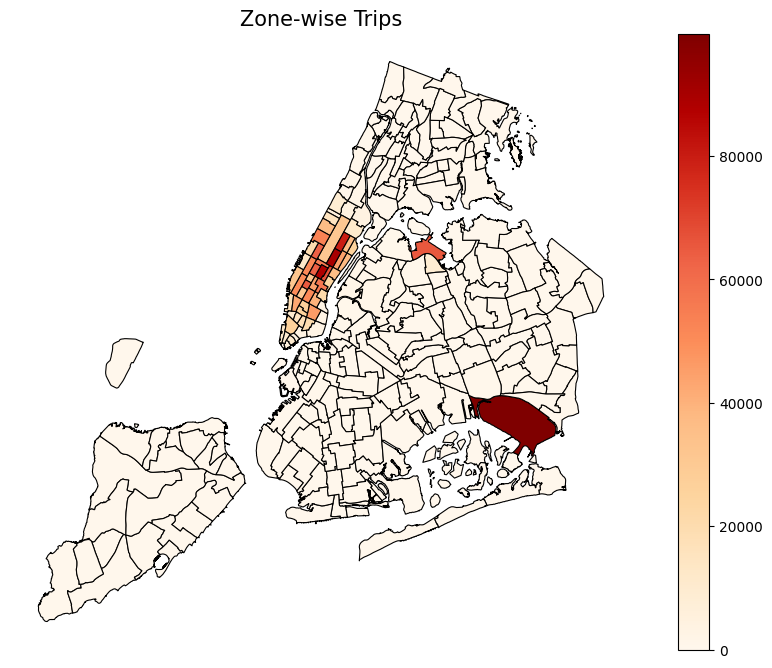

In [11]:
# Define figure and axis


# Plot the map and display it

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

zones = gpd.read_file(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\taxi_zones\\taxi_zones.shp")
trip_records = pd.read_parquet(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet")

zones = zones.rename(columns={"LocationID": "PULocationID"}) 
trip_records["PULocationID"] = trip_records["PULocationID"].astype(str)
zones["PULocationID"] = zones["PULocationID"].astype(str)
trip_counts = trip_records.groupby("PULocationID").size().reset_index(name="trip_count")
zones = zones.merge(trip_counts, on="PULocationID", how="left")
zones["trip_count"] = zones["trip_count"].fillna(0) 
fig, ax = plt.subplots(figsize=(12, 8))
zones.plot(column="trip_count", cmap="OrRd", linewidth=0.8, edgecolor="black", legend=True, ax=ax)
plt.title("Zone-wise Trips", fontsize=15)
plt.axis("off")
plt.show()


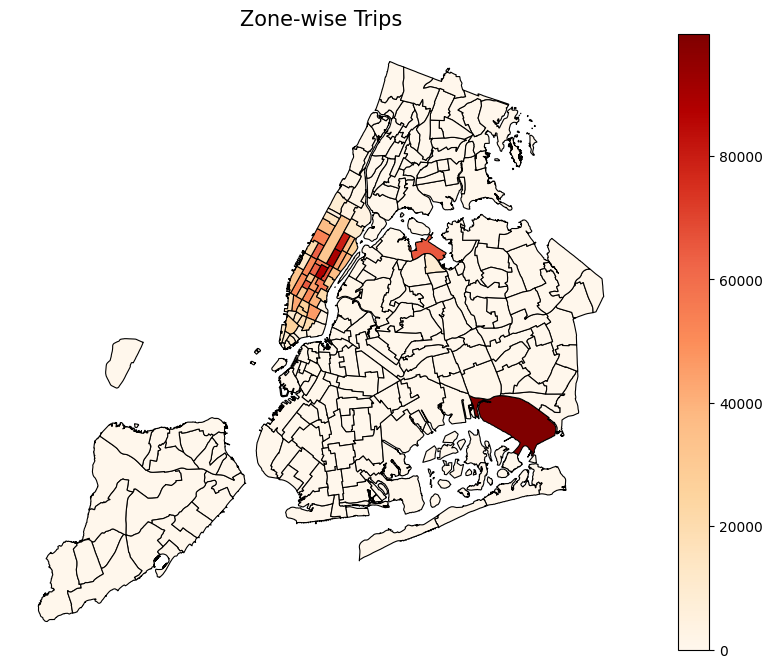

In [1]:
# can you try displaying the zones DF sorted by the number of trips?

# Define figure and axis


# Plot the map and display it

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

zones = gpd.read_file(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\taxi_zones\\taxi_zones.shp")
trip_records = pd.read_parquet(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet")

zones = zones.rename(columns={"LocationID": "PULocationID"}) 
trip_records["PULocationID"] = trip_records["PULocationID"].astype(str)
zones["PULocationID"] = zones["PULocationID"].astype(str)
trip_counts = trip_records.groupby("PULocationID").size().reset_index(name="trip_count")
zones = zones.merge(trip_counts, on="PULocationID", how="left")
zones["trip_count"] = zones["trip_count"].fillna(0)
zones_sorted = zones.sort_values(by="trip_count", ascending=False)
fig, ax = plt.subplots(figsize=(12, 8))
zones_sorted.plot(column="trip_count", cmap="OrRd", linewidth=0.8, edgecolor="black", legend=True, ax=ax)
plt.title("Zone-wise Trips", fontsize=15)
plt.axis("off")
plt.show()


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [12]:
# Find routes which have the slowest speeds at different times of the day

import pandas as pd

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"  # Update with the correct file path
df = pd.read_parquet(file_path)

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["travel_time"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
route_stats = (
    df.groupby(["PULocationID", "DOLocationID", "pickup_hour"])
    .agg(avg_travel_time=("travel_time", "mean"), avg_distance=("trip_distance", "mean"))
    .reset_index()
)
route_stats["speed"] = route_stats["avg_distance"] / route_stats["avg_travel_time"]
slowest_routes = route_stats.sort_values(by=["pickup_hour", "speed"]).groupby("pickup_hour").first().reset_index()
slowest_routes.to_csv(f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\CSV\\slowest_routes.csv", index=False)
print(slowest_routes.head())


   pickup_hour  PULocationID  DOLocationID  avg_travel_time  avg_distance  \
0            0           265           216        -0.250000          8.91   
1            1           246           255        -0.875000          5.86   
2            2            13            13         0.344444          0.00   
3            3           265           210        -0.183333         24.13   
4            4           265            39        -0.200000          8.86   

        speed  
0  -35.640000  
1   -6.697143  
2    0.000000  
3 -131.618182  
4  -44.300000  


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

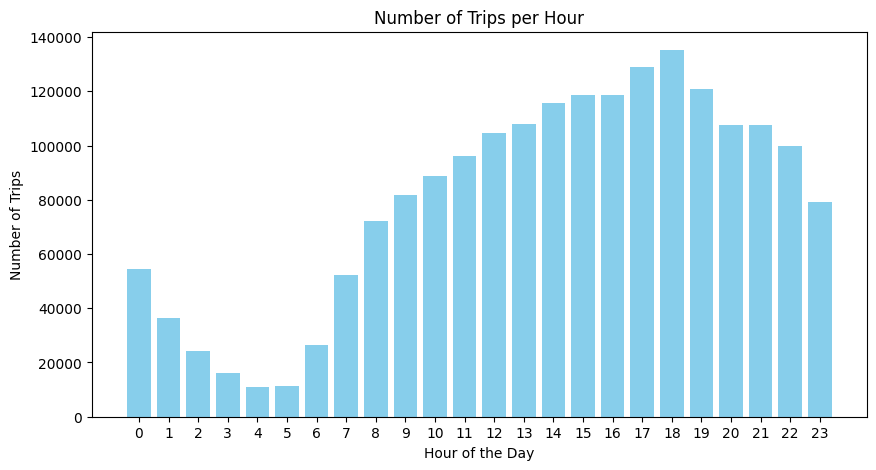

Busiest Hour: 18:00 with 135221 trips


In [14]:
# Visualise the number of trips per hour and find the busiest hour
import pandas as pd

file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"  # Update with the correct file path
df = pd.read_parquet(file_path)




df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["travel_time"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
trips_per_hour = df["pickup_hour"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.bar(trips_per_hour.index, trips_per_hour.values, color='skyblue')
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Trips")
plt.title("Number of Trips per Hour")
plt.xticks(range(24))
plt.show()

busiest_hour = trips_per_hour.idxmax()
print(f"Busiest Hour: {busiest_hour}:00 with {trips_per_hour.max()} trips")



Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

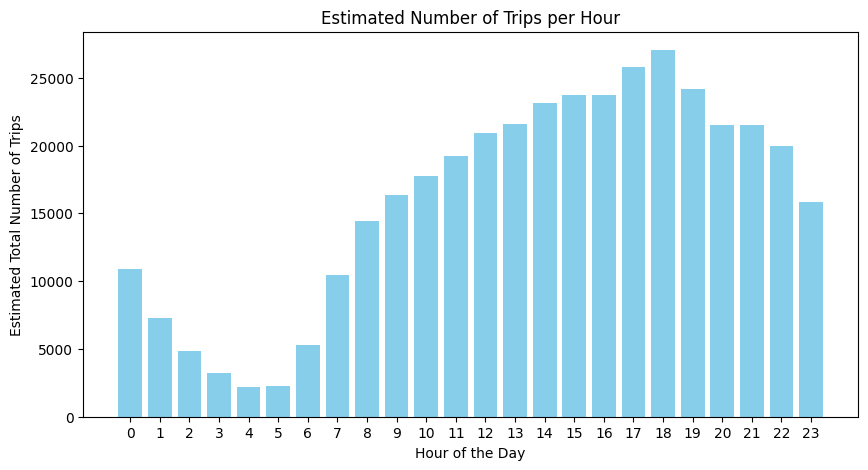

In [16]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
import pandas as pd
import matplotlib.pyplot as plt



file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"  # Update with the correct file path
df = pd.read_parquet(file_path)


sample_fraction = 5.0  


df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["travel_time"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
trips_per_hour = df["pickup_hour"].value_counts().sort_index() / sample_fraction
plt.figure(figsize=(10, 5))
plt.bar(trips_per_hour.index, trips_per_hour.values, color='skyblue')
plt.xlabel("Hour of the Day")
plt.ylabel("Estimated Total Number of Trips")
plt.title("Estimated Number of Trips per Hour")
plt.xticks(range(24))
plt.show()



**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

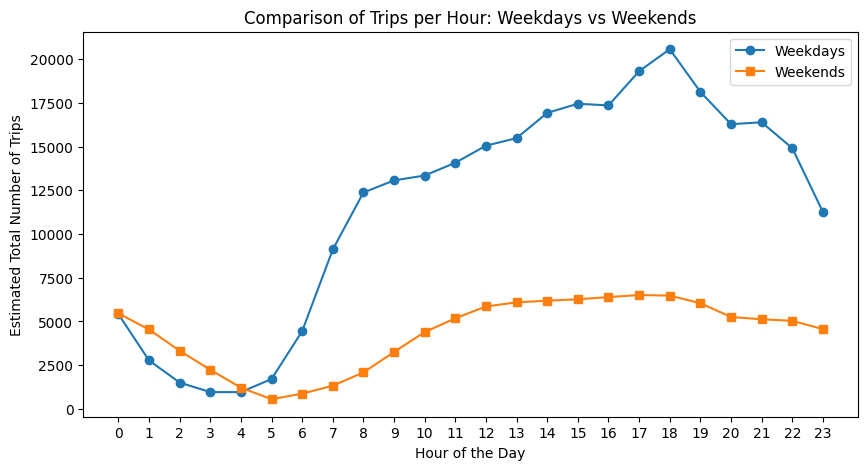

Busiest Hour (Weekdays): 18:00 with approximately 20564.6 trips
Busiest Hour (Weekends): 17:00 with approximately 6510.8 trips


In [17]:
# Compare traffic trends for the week days and weekends

import pandas as pd
import matplotlib.pyplot as plt
file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"  # Update with the correct file path
df = pd.read_parquet(file_path)
sample_fraction = 5.0


df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["travel_time"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.weekday
df["is_weekend"] = df["pickup_weekday"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")
trips_per_hour_weekday = df[df["is_weekend"] == "Weekday"]["pickup_hour"].value_counts().sort_index() / sample_fraction
trips_per_hour_weekend = df[df["is_weekend"] == "Weekend"]["pickup_hour"].value_counts().sort_index() / sample_fraction

plt.figure(figsize=(10, 5))
plt.plot(trips_per_hour_weekday.index, trips_per_hour_weekday.values, label="Weekdays", marker='o')
plt.plot(trips_per_hour_weekend.index, trips_per_hour_weekend.values, label="Weekends", marker='s')
plt.xlabel("Hour of the Day")
plt.ylabel("Estimated Total Number of Trips")
plt.title("Comparison of Trips per Hour: Weekdays vs Weekends")
plt.xticks(range(24))
plt.legend()
plt.show()

busiest_hour_weekday = trips_per_hour_weekday.idxmax()
busiest_hour_weekend = trips_per_hour_weekend.idxmax()
print(f"Busiest Hour (Weekdays): {busiest_hour_weekday}:00 with approximately {trips_per_hour_weekday.max()} trips")
print(f"Busiest Hour (Weekends): {busiest_hour_weekend}:00 with approximately {trips_per_hour_weekend.max()} trips")

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [18]:
# Find top 10 pickup and dropoff zones

import pandas as pd
import matplotlib.pyplot as plt
file_path = f"D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"  # Update with the correct file path
df = pd.read_parquet(file_path)
sample_fraction = 5.0


df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["travel_time"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.weekday
df["is_weekend"] = df["pickup_weekday"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")
trips_per_hour_weekday = df[df["is_weekend"] == "Weekday"]["pickup_hour"].value_counts().sort_index() / sample_fraction
trips_per_hour_weekend = df[df["is_weekend"] == "Weekend"]["pickup_hour"].value_counts().sort_index() / sample_fraction



top_pickup_zones = df["PULocationID"].value_counts().head(10)
top_dropoff_zones = df["DOLocationID"].value_counts().head(10)
print("Top 10 Pickup Zones:\n", top_pickup_zones)
print("Top 10 Dropoff Zones:\n", top_dropoff_zones)

Top 10 Pickup Zones:
 PULocationID
132    99825
237    89858
161    88434
236    79783
162    67452
138    65509
186    64820
230    63540
142    63242
170    56634
Name: count, dtype: int64
Top 10 Dropoff Zones:
 DOLocationID
236    84352
237    80371
161    74347
230    58899
170    56509
162    54060
142    53484
239    52795
141    50187
68     48517
Name: count, dtype: int64


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [2]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

import pandas as pd
import matplotlib.pyplot as plt
file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
sample_fraction = 5.0
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["travel_time"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.weekday
df["is_weekend"] = df["pickup_weekday"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")
trips_per_hour_weekday = df[df["is_weekend"] == "Weekday"]["pickup_hour"].value_counts().sort_index() / sample_fraction
trips_per_hour_weekend = df[df["is_weekend"] == "Weekend"]["pickup_hour"].value_counts().sort_index() / sample_fraction
pickup_counts = df["PULocationID"].value_counts()
dropoff_counts = df["DOLocationID"].value_counts()
pickup_dropoff_ratio = (pickup_counts / dropoff_counts).dropna().sort_values(ascending=False)
print("Top 10 Pickup Zones:\n", pickup_counts.head(10))
print("\nTop 10 Dropoff Zones:\n", dropoff_counts.head(10))
print("\nTop 10 Pickup/Dropoff Ratios:\n", pickup_dropoff_ratio.head(10))
print("\nBottom 10 Pickup/Dropoff Ratios:\n", pickup_dropoff_ratio.tail(10))


Top 10 Pickup Zones:
 PULocationID
132    99825
237    89858
161    88434
236    79783
162    67452
138    65509
186    64820
230    63540
142    63242
170    56634
Name: count, dtype: int64

Top 10 Dropoff Zones:
 DOLocationID
236    84352
237    80371
161    74347
230    58899
170    56509
162    54060
142    53484
239    52795
141    50187
68     48517
Name: count, dtype: int64

Top 10 Pickup/Dropoff Ratios:
 70     8.035230
132    4.193094
138    2.618056
186    1.543003
114    1.372102
43     1.340255
249    1.339106
162    1.247725
161    1.189476
100    1.187273
Name: count, dtype: float64

Bottom 10 Pickup/Dropoff Ratios:
 172    0.055556
245    0.050000
46     0.041667
1      0.041126
58     0.040000
109    0.033333
156    0.031250
27     0.031250
206    0.025000
221    0.023256
Name: count, dtype: float64


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [3]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

import pandas as pd
file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
night_hours = list(range(23, 24)) + list(range(0, 6))
night_trips = df[df["pickup_hour"].isin(night_hours)]
night_pickup_counts = night_trips["PULocationID"].value_counts()
night_dropoff_counts = night_trips["DOLocationID"].value_counts()
print("Top 10 Nighttime Pickup Zones:\n", night_pickup_counts.head(10))
print("\nTop 10 Nighttime Dropoff Zones:\n", night_dropoff_counts.head(10))


Top 10 Nighttime Pickup Zones:
 PULocationID
79     16614
132    15119
249    13288
48     11097
148    10373
114     9128
230     8689
186     7278
164     6815
68      6566
Name: count, dtype: int64

Top 10 Nighttime Dropoff Zones:
 DOLocationID
79     8715
48     7403
170    6681
68     6120
107    5999
141    5606
263    5437
249    5249
230    4990
229    4632
Name: count, dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [4]:
# Filter for night hours (11 PM to 5 AM)

import pandas as pd


file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["dropoff_hour"] = df["tpep_dropoff_datetime"].dt.hour
night_hours = list(range(23, 24)) + list(range(0, 6))
night_trips = df[df["pickup_hour"].isin(night_hours)]
print(night_trips.head())


    VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
3          2  2022-10-24 23:15:32   2022-10-24 23:15:42              1.0   
4          2  2022-10-25 03:45:46   2022-10-25 03:45:50              1.0   
10         2  2022-12-31 23:07:51   2022-12-31 23:19:58              1.0   
11         1  2023-01-01 00:18:29   2023-01-01 00:55:20              1.0   
12         2  2023-01-01 00:26:12   2023-01-01 00:28:13              1.0   

    trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
3            0.00         5.0                  N           211           211   
4            0.02         5.0                  N             1             1   
10           2.90         1.0                  N           263            41   
11          11.30         1.0                  N           163           225   
12           0.14         1.0                  N           163           162   

    payment_type  ...  mta_tax  tip_amount  tolls_amount  \
3 

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [5]:
# Analyse the fare per mile per passenger for different passenger counts

import pandas as pd


file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)


df["fare_amount"] = pd.to_numeric(df["fare_amount"], errors="coerce")
df["trip_distance"] = pd.to_numeric(df["trip_distance"], errors="coerce")
df["passenger_count"] = pd.to_numeric(df["passenger_count"], errors="coerce")
df = df[(df["fare_amount"] > 0) & (df["trip_distance"] > 0) & (df["passenger_count"] > 0)]
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]
df["fare_per_mile_per_passenger"] = df["fare_per_mile"] / df["passenger_count"]
analysis = df.groupby("passenger_count")["fare_per_mile_per_passenger"].describe()
print(analysis)



                     count       mean         std       min       25%  \
passenger_count                                                         
1.0              1359456.0  10.936012  124.156659  0.000164  5.691244   
2.0               275338.0   6.711594   86.481593  0.000130  2.725322   
3.0                68294.0   4.177712   55.356768  0.000450  1.851852   
4.0                37886.0   5.003928   70.475777  0.025000  1.372058   
5.0                24044.0   1.852822   13.867369  0.139535  1.132043   
6.0                15717.0   1.714545   16.840568  0.125000  0.962733   
8.0                    4.0   0.823828    0.273285  0.507872  0.643748   

                      50%       75%           max  
passenger_count                                    
1.0              7.172996  9.085366  28500.000000  
2.0              3.521127  4.452055   8000.000000  
3.0              2.370370  3.002713   4666.666667  
4.0              1.770833  2.250000   4750.000000  
5.0              1.414634  1.7

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [6]:
# Compare the average fare per mile for different days and for different times of the day
import pandas as pd

file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)


df["fare_amount"] = pd.to_numeric(df["fare_amount"], errors="coerce")
df["trip_distance"] = pd.to_numeric(df["trip_distance"], errors="coerce")
df["passenger_count"] = pd.to_numeric(df["passenger_count"], errors="coerce")
df = df[(df["fare_amount"] > 0) & (df["trip_distance"] > 0) & (df["passenger_count"] > 0)]
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]
df["fare_per_mile_per_passenger"] = df["fare_per_mile"] / df["passenger_count"]
analysis = df.groupby("passenger_count")["fare_per_mile_per_passenger"].describe()
print(analysis)



                     count       mean         std       min       25%  \
passenger_count                                                         
1.0              1359456.0  10.936012  124.156659  0.000164  5.691244   
2.0               275338.0   6.711594   86.481593  0.000130  2.725322   
3.0                68294.0   4.177712   55.356768  0.000450  1.851852   
4.0                37886.0   5.003928   70.475777  0.025000  1.372058   
5.0                24044.0   1.852822   13.867369  0.139535  1.132043   
6.0                15717.0   1.714545   16.840568  0.125000  0.962733   
8.0                    4.0   0.823828    0.273285  0.507872  0.643748   

                      50%       75%           max  
passenger_count                                    
1.0              7.172996  9.085366  28500.000000  
2.0              3.521127  4.452055   8000.000000  
3.0              2.370370  3.002713   4666.666667  
4.0              1.770833  2.250000   4750.000000  
5.0              1.414634  1.7

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

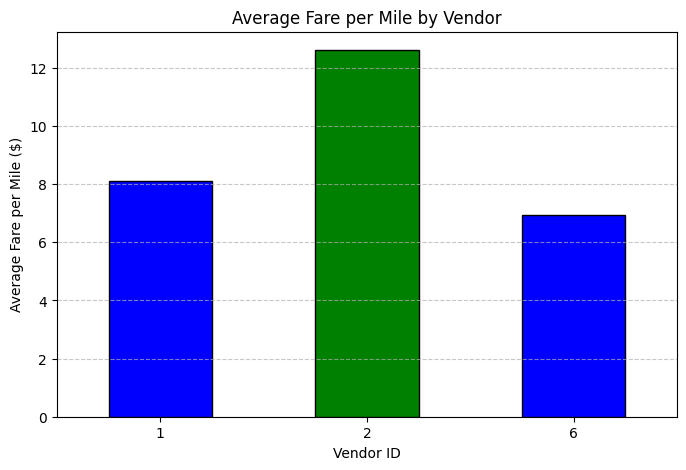

VendorID
1     8.103820
2    12.610848
6     6.950095
Name: fare_per_mile, dtype: float64


In [7]:
# Compare fare per mile for different vendors

import pandas as pd
import matplotlib.pyplot as plt

file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df["fare_amount"] = pd.to_numeric(df["fare_amount"], errors="coerce")
df["trip_distance"] = pd.to_numeric(df["trip_distance"], errors="coerce")
df["VendorID"] = pd.to_numeric(df["VendorID"], errors="coerce")
df = df[(df["fare_amount"] > 0) & (df["trip_distance"] > 0)]
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]
avg_fare_per_mile_vendor = df.groupby("VendorID")["fare_per_mile"].mean()
plt.figure(figsize=(8, 5))
avg_fare_per_mile_vendor.plot(kind="bar", color=["blue", "green"], edgecolor="black")
plt.xlabel("Vendor ID")
plt.ylabel("Average Fare per Mile ($)")
plt.title("Average Fare per Mile by Vendor")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
print(avg_fare_per_mile_vendor)


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [9]:
# Defining distance tiers
import pandas as pd



file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df["fare_amount"] = pd.to_numeric(df["fare_amount"], errors="coerce")
df["trip_distance"] = pd.to_numeric(df["trip_distance"], errors="coerce")
df = df[(df["fare_amount"] > 0) & (df["trip_distance"] > 0)]
bins = [0, 2, 5, 10, 20, float("inf")]  
labels = ["0-2 miles", "2-5 miles", "5-10 miles", "10-20 miles", "20+ miles"]
df["distance_tier"] = pd.cut(df["trip_distance"], bins=bins, labels=labels, right=False)
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]
distance_tier_stats = df.groupby("distance_tier", observed=False)["fare_per_mile"].describe()
print(distance_tier_stats)


                   count       mean         std       min       25%       50%  \
distance_tier                                                                   
0-2 miles      1005563.0  16.296068  185.531659  0.005263  7.285714  8.600000   
2-5 miles       523767.0   6.530129    1.633298  0.002326  5.525526  6.225895   
5-10 miles      165091.0   4.838846    0.928580  0.001220  4.274194  4.654088   
10-20 miles     143745.0   4.184777    0.600117  0.000543  3.856877  4.050847   
20+ miles        21214.0   3.710875    0.946753  0.000091  3.275620  3.448276   

                     75%           max  
distance_tier                           
0-2 miles      10.612245  28500.000000  
2-5 miles       7.124123    125.000000  
5-10 miles      5.175439     42.696629  
10-20 miles     4.360000     45.499139  
20+ miles       3.884702     49.308021  


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

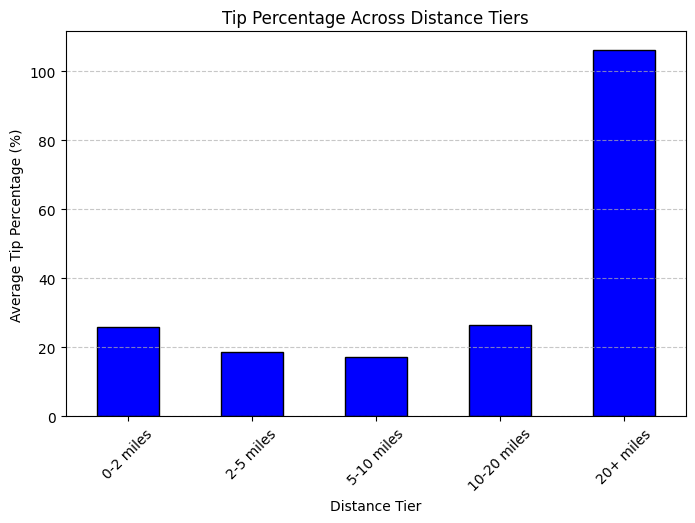

In [11]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

import pandas as pd
import matplotlib.pyplot as plt


file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)


df["fare_amount"] = pd.to_numeric(df["fare_amount"], errors="coerce")
df["tip_amount"] = pd.to_numeric(df["tip_amount"], errors="coerce")
df["trip_distance"] = pd.to_numeric(df["trip_distance"], errors="coerce")
df["passenger_count"] = pd.to_numeric(df["passenger_count"], errors="coerce")


df = df[(df["fare_amount"] > 0) & (df["tip_amount"] >= 0)]
df["tip_percentage"] = (df["tip_amount"] / df["fare_amount"]) * 100


bins = [0, 2, 5, 10, 20, float("inf")]
labels = ["0-2 miles", "2-5 miles", "5-10 miles", "10-20 miles", "20+ miles"]
df["distance_tier"] = pd.cut(df["trip_distance"], bins=bins, labels=labels, right=False)

tip_by_distance = df.groupby("distance_tier", observed=False)["tip_percentage"].mean()

plt.figure(figsize=(8, 5))
tip_by_distance.plot(kind="bar", color="blue", edgecolor="black")
plt.xlabel("Distance Tier")
plt.ylabel("Average Tip Percentage (%)")
plt.title("Tip Percentage Across Distance Tiers")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

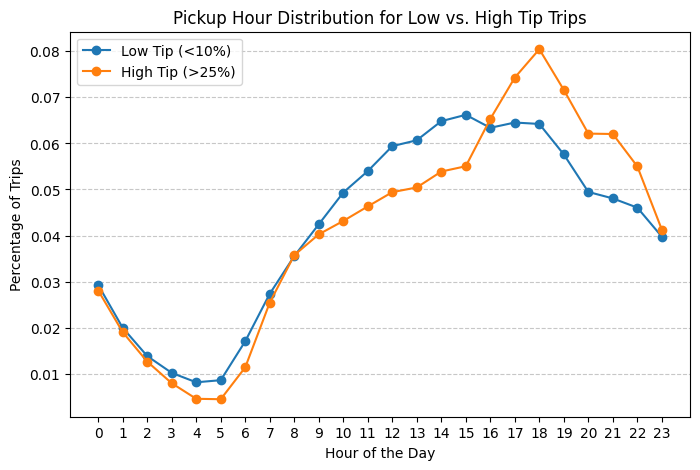

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)

# Ensure numeric values
df["fare_amount"] = pd.to_numeric(df["fare_amount"], errors="coerce")
df["tip_amount"] = pd.to_numeric(df["tip_amount"], errors="coerce")
df["trip_distance"] = pd.to_numeric(df["trip_distance"], errors="coerce")
df["passenger_count"] = pd.to_numeric(df["passenger_count"], errors="coerce")

# Filter valid trips
df = df[(df["fare_amount"] > 0) & (df["tip_amount"] >= 0)]

# Compute tip percentage
df["tip_percentage"] = (df["tip_amount"] / df["fare_amount"]) * 100

low_tip = df[df["tip_percentage"] < 10].copy()
high_tip = df[df["tip_percentage"] > 25].copy()

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
low_tip["pickup_hour"] = low_tip["tpep_pickup_datetime"].dt.hour
high_tip["pickup_hour"] = high_tip["tpep_pickup_datetime"].dt.hour

pickup_hour_comparison = pd.DataFrame({
    "Low Tip (<10%)": low_tip["pickup_hour"].value_counts(normalize=True).sort_index(),
    "High Tip (>25%)": high_tip["pickup_hour"].value_counts(normalize=True).sort_index()
}).fillna(0)

pickup_hour_comparison.plot(kind="line", figsize=(8, 5), marker="o")
plt.xlabel("Hour of the Day")
plt.ylabel("Percentage of Trips")
plt.title("Pickup Hour Distribution for Low vs. High Tip Trips")
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()
plt.show()


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

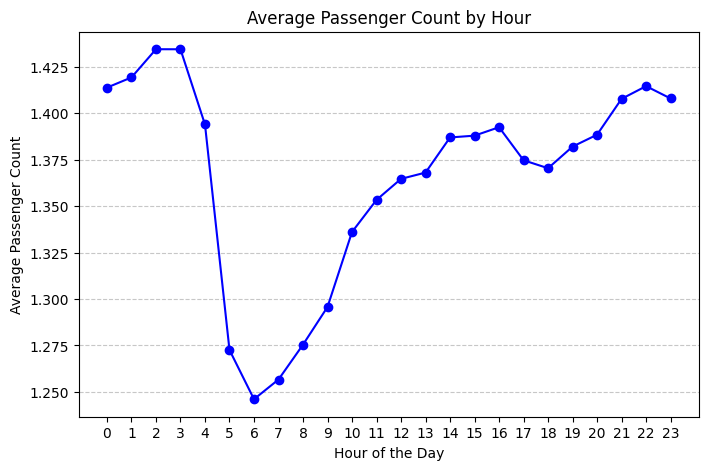

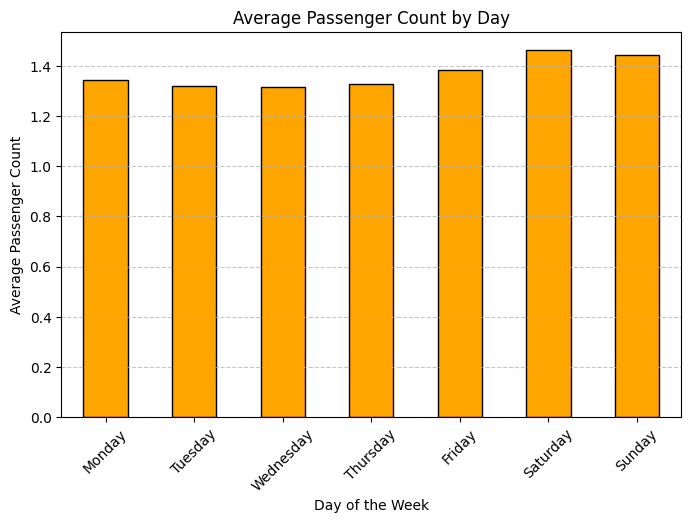

In [15]:
# See how passenger count varies across hours and days

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()


passengers_by_hour = df.groupby("pickup_hour")["passenger_count"].mean()


passengers_by_day = df.groupby("pickup_day")["passenger_count"].mean()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
passengers_by_day = passengers_by_day.reindex(day_order)


plt.figure(figsize=(8, 5))
passengers_by_hour.plot(kind="line", marker="o", color="blue")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Passenger Count")
plt.title("Average Passenger Count by Hour")
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

plt.figure(figsize=(8, 5))
passengers_by_day.plot(kind="bar", color="orange", edgecolor="black")
plt.xlabel("Day of the Week")
plt.ylabel("Average Passenger Count")
plt.title("Average Passenger Count by Day")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

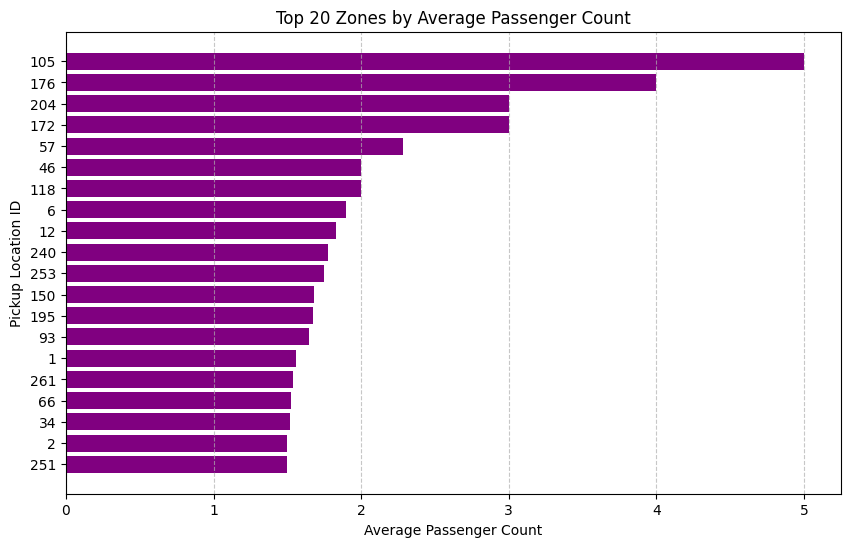

In [16]:
# How does passenger count vary across zones
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load data
trip_data_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
zones_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\taxi_zones\\taxi_zones.shp"

df = pd.read_parquet(trip_data_path)
zones = gpd.read_file(zones_path)


df["PULocationID"] = df["PULocationID"].astype(str)
zones = zones.rename(columns={"LocationID": "PULocationID"})
zones["PULocationID"] = zones["PULocationID"].astype(str)


passenger_per_zone = df.groupby("PULocationID")["passenger_count"].mean().reset_index()
passenger_per_zone.rename(columns={"passenger_count": "avg_passenger_count"}, inplace=True)


zones = zones.merge(passenger_per_zone, on="PULocationID", how="left")
zones["avg_passenger_count"] = zones["avg_passenger_count"].fillna(0)  # Fill missing values with 0


top_zones = passenger_per_zone.sort_values(by="avg_passenger_count", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_zones["PULocationID"], top_zones["avg_passenger_count"], color="purple")
plt.xlabel("Average Passenger Count")
plt.ylabel("Pickup Location ID")
plt.title("Top 20 Zones by Average Passenger Count")
plt.gca().invert_yaxis()  # Invert for better readability
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


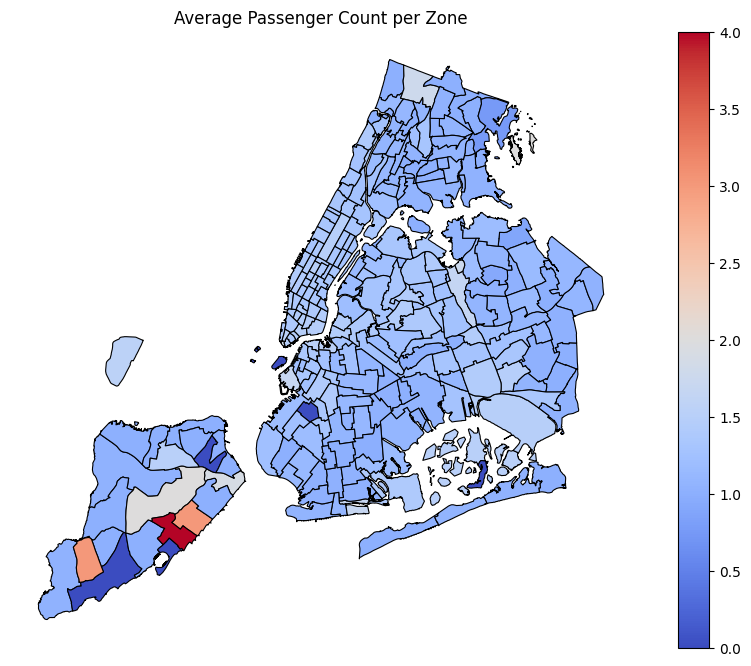

In [18]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load data
trip_data_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
zones_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\taxi_zones\\taxi_zones.shp"

df = pd.read_parquet(trip_data_path)
zones = gpd.read_file(zones_path)


df["PULocationID"] = df["PULocationID"].astype(str)
zones = zones.rename(columns={"LocationID": "PULocationID"})
zones["PULocationID"] = zones["PULocationID"].astype(str)


avg_passenger_count = df.groupby("PULocationID")["passenger_count"].mean().reset_index()
avg_passenger_count.rename(columns={"passenger_count": "avg_passenger_count"}, inplace=True)


zones_with_trips = zones.merge(avg_passenger_count, on="PULocationID", how="left")
zones_with_trips["avg_passenger_count"] = zones_with_trips["avg_passenger_count"].fillna(0)  # Fill missing values


fig, ax = plt.subplots(figsize=(12, 8))
zones_with_trips.plot(column="avg_passenger_count", cmap="coolwarm", linewidth=0.8, edgecolor="black", legend=True, ax=ax)
plt.title("Average Passenger Count per Zone")
plt.axis("off")
plt.show()



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

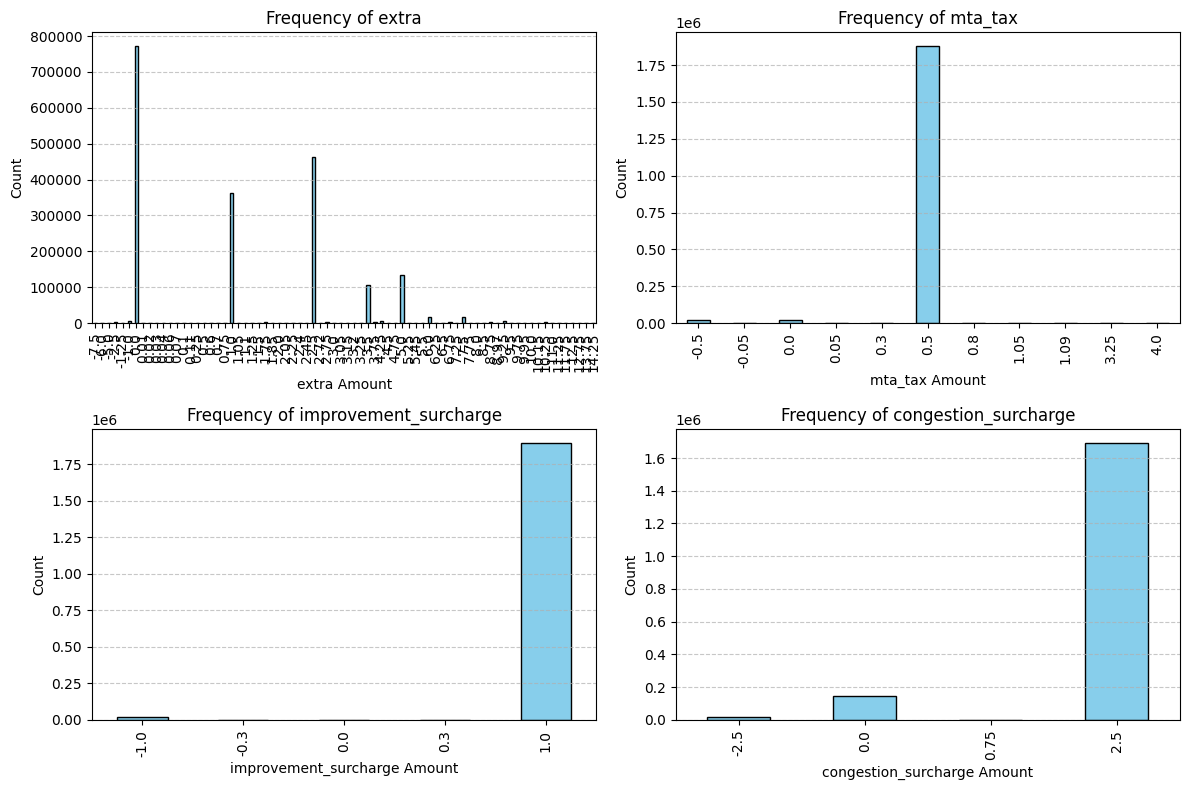

In [17]:
# How often is each surcharge applied?

import pandas as pd
import matplotlib.pyplot as plt

file_path = "D:\\WorkSpace\\Assignment\\EDA_Optimising_NYC_Taxis\\Data\\Combine\\Combine_yellow_tripdata_2023.parquet"
df = pd.read_parquet(file_path)

surcharge_columns = ["extra", "mta_tax", "improvement_surcharge", "congestion_surcharge"]
surcharge_counts = {col: df[col].value_counts().sort_index() for col in surcharge_columns}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (col, counts) in zip(axes.flatten(), surcharge_counts.items()):
    counts.plot(kind="bar", ax=ax, color="skyblue", edgecolor="black")
    ax.set_title(f"Frequency of {col}")
    ax.set_xlabel(f"{col} Amount")
    ax.set_ylabel("Count")
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
Deploy more taxis in residential zones in the Morning.
Focus fleet in business and commercial areas in the Evening.
Increase coverage around bars, airports, and entertainment hubs at late night.

Higher base fares during peak business hours in demand-heavy zones.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
Deploy more taxis in outer boroughs and residential areas.
Increase fleet around key transit hubs.
Ensure coverage near airports.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.